In [1]:
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from PIL import Image
import pandas as pd
import seaborn as sns

In [2]:
trainingSetpath = "./trainingSample/trainingSample"
images_mnist = {}

for folder in os.listdir(trainingSetpath):  # Use trainingSetpath_path here
    folder_path = os.path.join(trainingSetpath, folder)
    if os.path.isdir(folder_path):
        images1= []
        for filename in os.listdir(folder_path):
            if filename.endswith((".png", ".jpg", ".jpeg")):
                img = Image.open(os.path.join(folder_path, filename))
                img = img.convert("RGB")
                img = img.resize((224, 224))
                images1.append(np.array(img)) 

        if images1:  # Ensure non-empty images list before converting
            images_mnist[folder] = np.array(images1)

# Print shape of each folder's image set
for folder, images in  images_mnist.items():
    print(f"Folder: {folder}, Images Shape: {images.shape}")

Folder: 0, Images Shape: (60, 224, 224, 3)
Folder: 1, Images Shape: (60, 224, 224, 3)
Folder: 2, Images Shape: (60, 224, 224, 3)
Folder: 3, Images Shape: (60, 224, 224, 3)
Folder: 4, Images Shape: (60, 224, 224, 3)
Folder: 5, Images Shape: (60, 224, 224, 3)
Folder: 6, Images Shape: (60, 224, 224, 3)
Folder: 7, Images Shape: (60, 224, 224, 3)
Folder: 8, Images Shape: (60, 224, 224, 3)
Folder: 9, Images Shape: (60, 224, 224, 3)


In [3]:
dataCoil20_path = "./coil-20"
images_coil = {}

for folder in os.listdir(dataCoil20_path):  # Use dataCoil20_path here
    folder_path = os.path.join(dataCoil20_path, folder)
    if os.path.isdir(folder_path):
        images1= []
        for filename in os.listdir(folder_path):
            if filename.endswith((".png", ".jpg", ".jpeg")):
                img = Image.open(os.path.join(folder_path, filename))
                img = img.convert("RGB")
                img = img.resize((224, 224))
                images1.append(np.array(img))

        if images1:  # Ensure non-empty images list before converting
            images_coil[folder] = np.array(images1)

# Print shape of each folder's image set
for folder, images in images_coil.items():
    print(f"Folder: {folder}, Images Shape: {images.shape}")

Folder: 1, Images Shape: (72, 224, 224, 3)
Folder: 10, Images Shape: (72, 224, 224, 3)
Folder: 11, Images Shape: (72, 224, 224, 3)
Folder: 12, Images Shape: (72, 224, 224, 3)
Folder: 13, Images Shape: (72, 224, 224, 3)
Folder: 14, Images Shape: (72, 224, 224, 3)
Folder: 15, Images Shape: (72, 224, 224, 3)
Folder: 16, Images Shape: (72, 224, 224, 3)
Folder: 17, Images Shape: (72, 224, 224, 3)
Folder: 18, Images Shape: (72, 224, 224, 3)
Folder: 19, Images Shape: (72, 224, 224, 3)
Folder: 2, Images Shape: (72, 224, 224, 3)
Folder: 20, Images Shape: (72, 224, 224, 3)
Folder: 3, Images Shape: (72, 224, 224, 3)
Folder: 4, Images Shape: (72, 224, 224, 3)
Folder: 5, Images Shape: (72, 224, 224, 3)
Folder: 6, Images Shape: (72, 224, 224, 3)
Folder: 7, Images Shape: (72, 224, 224, 3)
Folder: 8, Images Shape: (72, 224, 224, 3)
Folder: 9, Images Shape: (72, 224, 224, 3)


In [4]:
files = {}
path = "./coil-20"
for i in range(20) : 
    im_path = path+f'/{i+1}'
    files[i] = []
    for j in range(72) : 
        files[i].append(im_path+f'\\obj{i+1}__{j}.png')


In [5]:
# Directory containing images
def from_img_togif(files,i=[1]) : 
                
    # Get full paths of images
    image_files = files

    # Open images and convert to RGBA mode for consistency
    images = [Image.open(img).convert("RGBA") for img in image_files]

    # Save as GIF
    images[0].save(f"coil-20-gifs/output{i[0]}.gif", save_all=True, append_images=images[1:], duration=500, loop=0)

    print(f"GIF created successfully: output{i[0]}.gif")
    i[0]+=1

try  : 
    os.mkdir('coil-20-gifs')
except : 
    print("Already created")


Already created


In [6]:
for i in files : 
    from_img_togif(files[i])

GIF created successfully: output1.gif
GIF created successfully: output2.gif
GIF created successfully: output3.gif
GIF created successfully: output4.gif
GIF created successfully: output5.gif
GIF created successfully: output6.gif
GIF created successfully: output7.gif
GIF created successfully: output8.gif
GIF created successfully: output9.gif
GIF created successfully: output10.gif
GIF created successfully: output11.gif
GIF created successfully: output12.gif
GIF created successfully: output13.gif
GIF created successfully: output14.gif
GIF created successfully: output15.gif
GIF created successfully: output16.gif
GIF created successfully: output17.gif
GIF created successfully: output18.gif
GIF created successfully: output19.gif
GIF created successfully: output20.gif


In [7]:
#task 3 COIL20
labels = sorted(os.listdir("coil-20"),key=lambda x : int(x))

In [8]:
flattend_imags = {}
for folder in images_coil:
    images_cp = []
    for i in range(len(images_coil[folder])):
        # Convert to grayscale and flatten the image
        images_cp.append(np.array(Image.fromarray(images_coil[folder][i]).resize((64,64)).convert('')).flatten())
    flattend_imags[folder] = np.array(images_cp)
non_scaled_images = flattend_imags.copy()


In [9]:
#Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for folder in flattend_imags:
    flattend_imags[folder] = scaler.fit_transform(flattend_imags[folder])


In [10]:
df = pd.DataFrame(non_scaled_images['2'])


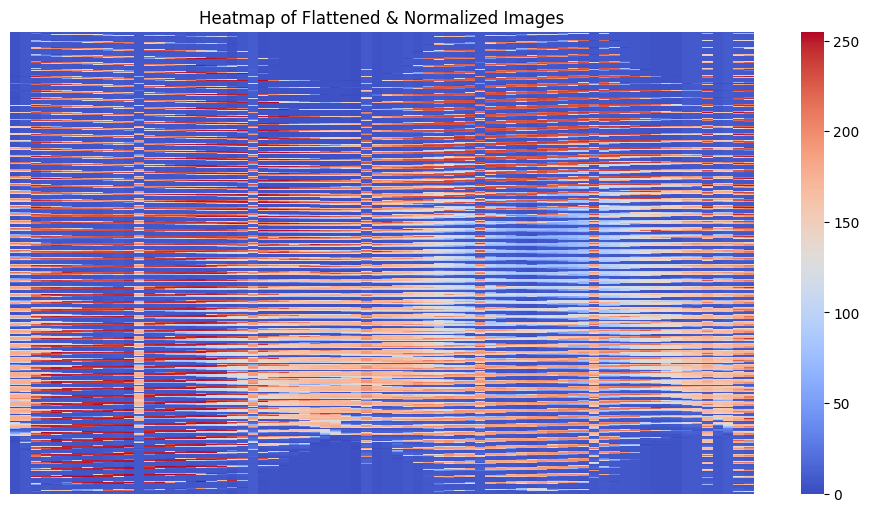

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.iloc[:, :].T, cmap="coolwarm", xticklabels=False, yticklabels=False)
plt.title("Heatmap of Flattened & Normalized Images")
plt.show()


In [12]:
'''''''''
from sklearn.decomposition import PCA

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df)  # Exclude label column

# Convert to DataFrame
df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["Label"] = labels

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Label", palette="viridis", alpha=0.7)
plt.title("PCA Bi-Plot of COIL-20 Images")
plt.show()

'''''''''

'\nfrom sklearn.decomposition import PCA\n\n# Reduce dimensions to 2D for visualization\npca = PCA(n_components=2)\npca_result = pca.fit_transform(df)  # Exclude label column\n\n# Convert to DataFrame\ndf_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])\ndf_pca["Label"] = labels\n\n# Scatter Plot\nplt.figure(figsize=(8,6))\nsns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Label", palette="viridis", alpha=0.7)\nplt.title("PCA Bi-Plot of COIL-20 Images")\nplt.show()\n\n'

In [13]:
flattend_imags_cnn = {}
for folder in images_mnist:
    images_cp = []
    for i in range(len(images_mnist[folder])):
        # Convert to grayscale and flatten the image
        images_cp.append(np.array(Image.fromarray(images_mnist[folder][i]).resize((64,64)).convert('')).flatten())
    flattend_imags_cnn[folder] = np.array(images_cp)


In [14]:
from sklearn.decomposition import PCA

images_cnn = []
labels = []
for folder , images in flattend_imags_cnn.items():
    for image in flattend_imags_cnn[folder] : 
        images_cnn.append(image)
    labels.extend([folder] * len(images))  # Store corresponding labels# Reduce dimensionality for visualization

images_cnn = np.vstack(images_cnn) 
scaled_images = scaler.fit_transform(images_cnn)

# Apply PCA
pca = PCA(n_components=10)  # Reduce to 10 components
data_pca = pca.fit_transform(scaled_images)

# Convert results into a Pandas DataFrame with labels
df_pca = pd.DataFrame(data_pca, columns=[f'PC{i+1}' for i in range(10)])
df_pca["label"] = labels  # Keep labels for tracking

# Display first few rows
print(df_pca.head())

          PC1        PC2        PC3        PC4        PC5        PC6  \
0   76.765607  -6.637342  -2.431202  -3.532594  -5.262163 -15.468355   
1   31.522565 -25.658876 -13.094357  -6.361955 -24.165692  13.978979   
2  104.427701 -48.386139 -26.750667  -3.772478   4.082319 -23.859913   
3   -3.679669 -26.288581   7.286253  -9.830074 -16.276778  -1.615047   
4   36.473429 -53.817898  -4.696067  15.834712  11.858848 -34.380259   

         PC7        PC8        PC9       PC10 label  
0  28.852781  -3.136574  -3.675503 -10.009702     0  
1  25.471883  11.503947   9.976864 -12.492420     0  
2  28.883038 -16.857935  10.988444  13.577533     0  
3 -10.172406  -4.025695  16.297852  -3.640748     0  
4  13.349992   3.736053  -1.023093 -18.186589     0  


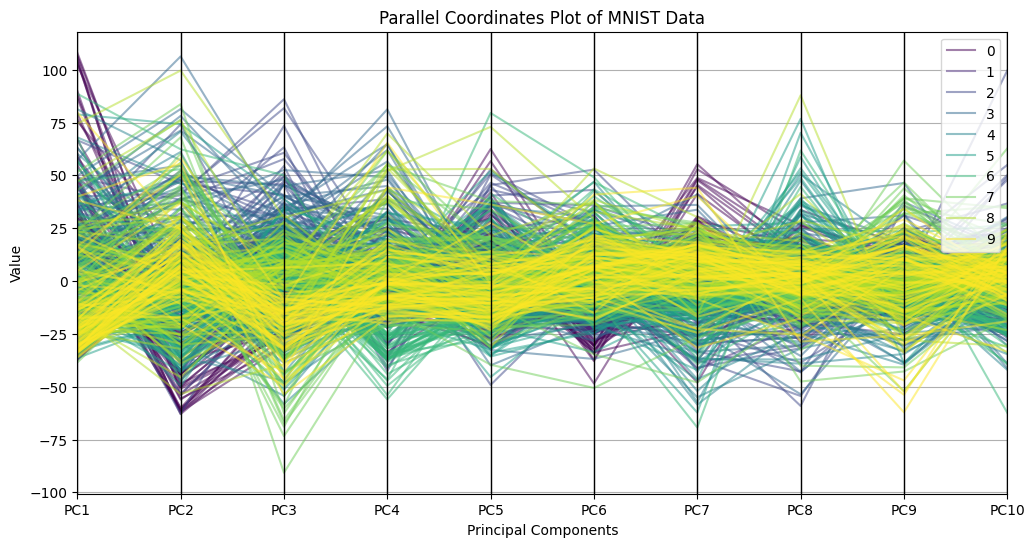

In [15]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(12, 6))
parallel_coordinates(df_pca, 'label', colormap='viridis', alpha=0.5)
plt.title('Parallel Coordinates Plot of MNIST Data')
plt.xlabel('Principal Components')
plt.ylabel('Value')
plt.show()

In [16]:
pca = PCA(n_components=2)  # Reduce to 10 components

pca_2 = pca.fit_transform(scaled_images)

<Axes: xlabel='PC1', ylabel='PC2'>

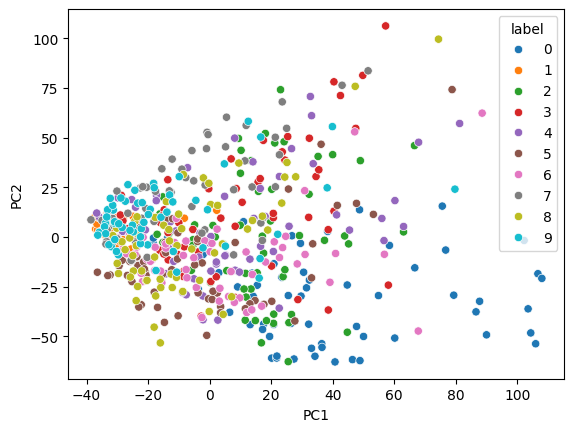

In [17]:
df_pca_2 = pd.DataFrame(pca_2 , columns=[f'PC{i+1}' for i in range(2)])
df_pca_2['label'] = labels

sns.scatterplot(x = df_pca_2['PC1'] ,y =  df_pca_2['PC2'] , hue = df_pca_2["label"])

In [18]:
pca = PCA(n_components=3)  # Reduce to 10 components

pca_3 = pca.fit_transform(scaled_images)

In [19]:
df_pca_3 = pd.DataFrame(pca_3 , columns=[f'PC{i+1}' for i in range(3)])
df_pca_3['label'] = labels



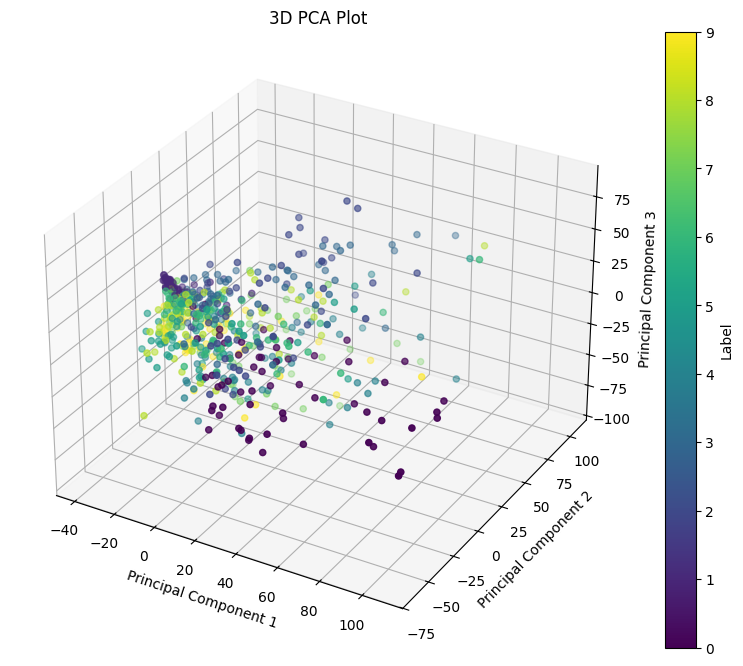

In [20]:
from mpl_toolkits.mplot3d import Axes3D

# Assuming df_pca_3 contains the first 3 principal components and labels
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for PC1, PC2, PC3
scatter = ax.scatter(df_pca_3['PC1'], df_pca_3['PC2'], df_pca_3['PC3'], c=df_pca_3['label'].astype('category').cat.codes, cmap='viridis')

# Adding labels to axes
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Adding a color bar to indicate label mappings
cbar = plt.colorbar(scatter, ax=ax, label='Label')

# Title of the plot
ax.set_title('3D PCA Plot')

# Show the plot
plt.show()


In [21]:
pca_2_coil = PCA(n_components=2)
scaled_images_coil  = []
labels_coil = []
for folder in non_scaled_images : 
    for image in non_scaled_images[folder] : 
        scaled_images_coil.append(image)
    labels_coil.extend([folder]*len(non_scaled_images[folder]))
scaled_images_coil = scaler.fit_transform(np.vstack(scaled_images_coil))

pca_2_coil = pca_2_coil.fit_transform(scaled_images_coil)

<Axes: xlabel='PC1', ylabel='PC2'>

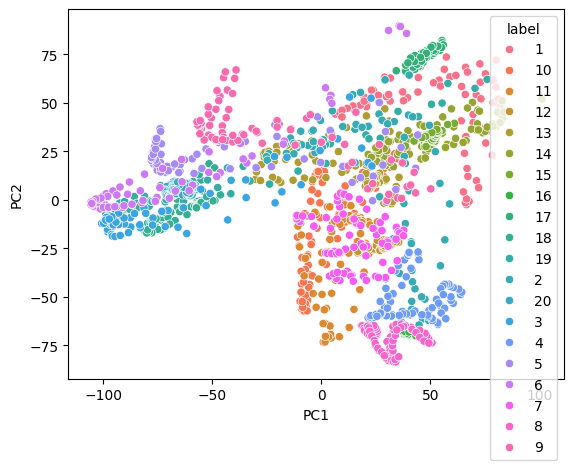

In [22]:
df_pca2_coil  = pd.DataFrame(pca_2_coil , columns = [f"PC{i+1}" for i in range(2)])
df_pca2_coil['label'] = labels_coil
sns.scatterplot(x = df_pca2_coil['PC1'] , y = df_pca2_coil['PC2'] , hue = df_pca2_coil['label'] )

In [23]:
df_pca2_coil

,PC1,PC2,label
0,15.061331,46.603554,1
1,20.913063,48.710721,1
2,78.762112,49.972988,1
3,75.916866,35.414259,1
4,75.365205,29.204367,1
...,...,...,...
1435,-48.334699,31.002265,9
1436,-47.847138,56.174892,9
1437,-44.026036,65.855268,9
1438,-45.253246,30.930562,9


In [ ]:
"""""""""""
from sklearn.manifold import TSNE
import umap
import nxcurve
0

# Apply UMAP (2D & 3D)
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(scaled_images)
umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(scaled_images)
"""""""""


'""\nfrom sklearn.manifold import TSNE\nimport umap\nimport nxcurve\n\n\n# Apply UMAP (2D & 3D)\numap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(scaled_images)\numap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(scaled_images)\n'

In [25]:
from sklearn.manifold import TSNE

tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(scaled_images)
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42).fit_transform(scaled_images)



In [26]:
df_tsne = pd.DataFrame(tsne_2d , columns=['Col1' , 'Col2'])


In [27]:
df_original = pd.DataFrame(scaled_images)


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 10  # Assuming 10 classes in MNIST
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Apply K-Means on different feature spaces
clusters_original = kmeans.fit_predict(df_original)
clusters_pca = kmeans.fit_predict(df_pca)
clusters_tsne = kmeans.fit_predict(df_tsne)

# Evaluate clustering using silhouette score (higher is better)
scores = {
    "Original": silhouette_score(df_original, clusters_original),
    "PCA": silhouette_score(df_pca, clusters_pca),
    "t-SNE": silhouette_score(df_tsne, clusters_tsne),
}

# Print silhouette scores
print("Silhouette Scores for K-Means Clustering:")
for method, score in scores.items():
    print(f"{method}: {score:.4f}")


Silhouette Scores for K-Means Clustering:
Original: 0.0143
PCA: 0.2053
t-SNE: 0.3812


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

k = 5  # Choose an appropriate k for KNN

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(scaled_images, labels, test_size=0.2, random_state=42)
X_train_pca, X_test_pca = train_test_split(data_pca, test_size=0.2, random_state=42)
X_train_tsne, X_test_tsne = train_test_split(tsne_2d, test_size=0.2, random_state=42)

# Train K-NN on different feature spaces
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)
acc_original = accuracy_score(y_test, knn.predict(X_test))

knn.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, knn.predict(X_test_pca))


knn.fit(X_train_tsne, y_train)
acc_tsne = accuracy_score(y_test, knn.predict(X_test_tsne))


# Print accuracy scores
print("\nK-NN Accuracy Scores:")
print(f"Original: {acc_original:.4f}")
print(f"PCA: {acc_pca:.4f}")
print(f"t-SNE: {acc_tsne:.4f}")



K-NN Accuracy Scores:
Original: 0.7667
PCA: 0.7500
t-SNE: 0.7250
